# Resampling activity distribution for fixed-point analysis

Note: this may require a larger validation set than the one that we trained the current models on.

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.core.pylabtools import figsize

import seaborn as sns

import numpy as np
import pandas as pd

from tqdm import tqdm
import torch

import sys
sys.path.append('..')

In [2]:
from src.utilities.samplers import previous_activity_sampler, wide_normal_sampler, resample_activity
from src.models.TTA_model import ClassifierWithTTA
from src.data.image_data import balanced_train_subsets

W1220 15:48:32.757000 5937 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


import error: No module named 'triton'


## Does the initial CLS token distribution impact the performance of the network?

Every network will (I think) have a fixed point distribution associated with it. The thing that makes the fixed-point special is that it is a pair of distribution and network. The distribution is the fixed-point of the network, and the network is optimal for that distribution.

### Question 1: how much does network performance depend on distribution that it is trained on?


In [3]:
cls_model = ClassifierWithTTA.from_pretrained('../experiments_base/sweeps/2025-11-13(16:04:10)-base_training/1/checkpoints/full/best')
cls_model.to('mps')
image_data, _ = balanced_train_subsets(train_fraction=1, split='valid') 

Loading weights from local directory


/Users/luke/Documents/activeProjects/TTA_working/analysis/../src/data/image_data.py:28: UserWarning: You are not fetching train data
  warnings.warn("You are not fetching train data")


In [4]:
cls_model.embedding.randomized_CLS

<function src.utilities.samplers.normal_sampler(patch_embeddings: torch.Tensor) -> torch.Tensor>

In [5]:
baseline = []
dl = torch.utils.data.DataLoader(image_data, batch_size=32, shuffle=False)

for batch in tqdm(iter(dl)):
    images, gts = batch
    baseline.append(cls_model.classify( images.to('mps')))

baseline = torch.concat(baseline).to('cpu')

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 313/313 [00:59<00:00,  5.25it/s]


In [6]:
(baseline == image_data[:][1]).to(float).mean()

tensor(0.7498, dtype=torch.float64)

In [7]:
cls_model.embedding.randomized_CLS = lambda batch: previous_activity_sampler('./activity_data_val.pt', batch)

In [8]:
newdist = []
dl = torch.utils.data.DataLoader(image_data, batch_size=32, shuffle=False)

for batch in tqdm(iter(dl)):
    images, gts = batch
    newdist.append(cls_model.classify( images.to('mps')))

newdist = torch.concat(newdist).to('cpu')

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 313/313 [02:07<00:00,  2.45it/s]


In [9]:
(newdist == image_data[:][1]).to(float).mean()

tensor(0.7464, dtype=torch.float64)

Hmmm. That's not a good sign for this direction. Does the input distribution really not matter?

In [10]:
cls_model.embedding.randomized_CLS = wide_normal_sampler

In [11]:
newdist = []
dl = torch.utils.data.DataLoader(image_data, batch_size=32, shuffle=False)

for batch in tqdm(iter(dl)):
    images, gts = batch
    newdist.append(cls_model.classify( images.to('mps')))

newdist = torch.concat(newdist).to('cpu')

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 313/313 [01:01<00:00,  5.09it/s]


In [12]:
(newdist == image_data[:][1]).to(float).mean()

tensor(0.7285, dtype=torch.float64)

Yeah, wow. Looks like the output activity is quite robust to changes in the activity distribution. This argues that, essentially, the output distribution is always the fixed point. Glad I tested this now.

It's a bit disappointing, but it raises a host of other interesting questions:
1. Is there a way to train networks to induces them to care more about the distribution of outputs?
2. Can I simply re-apply the network to activity distributions with multiple decodings to refine its outputs?
3. Is this behavior maintained under corruptions, can it be used as a sign of well-adaptedness?
4. Does this also apply to the model without randomness?

I really do need to check on the TTA behavior of these network.

### Iterated application of the network.

If I use network activity distributions from previous samples, do I see improvement in the classification performance?

1. The first time I ran this, the data was accidentally shuffled. Same performance as above 74.8%

In [3]:
test_dataset = torch.load('activity_data_test_unshuffled.pt')
correct_preds = test_dataset['predictions'].mode().values == test_dataset['gts']

In [4]:
cls_model = ClassifierWithTTA.from_pretrained('../experiments_base/sweeps/2025-11-13(16:04:10)-base_training/1/checkpoints/full/best')
cls_model.to('mps')
image_data, _ = balanced_train_subsets(train_fraction=1, split='valid') 

Loading weights from local directory


/Users/luke/Documents/activeProjects/TTA_working/analysis/../src/data/image_data.py:28: UserWarning: You are not fetching train data
  warnings.warn("You are not fetching train data")


Make sure that the labels line up:

In [109]:
(test_dataset['gts'] == image_data[:][1]).all()

tensor(True)

In [10]:
repeat_predictions = []

for i in tqdm(range(len(image_data))):
    inputs = image_data[i][0].repeat(50, 1, 1, 1).to('mps')
    prev_activity = test_dataset['activity'][i]
    cls_model.embedding.randomized_CLS = lambda batch: resample_activity(prev_activity, batch)

    preds = cls_model.classify(inputs).detach().cpu()
    repeat_predictions.append(preds)
    

100%|█████████████████████████████████████| 10000/10000 [51:21<00:00,  3.25it/s]


In [11]:
repeat_predictions = torch.stack(repeat_predictions)

In [12]:
correct_repeats = repeat_predictions.mode().values == image_data[:][1]

In [13]:
correct_repeats.float().mean()

tensor(0.7500)

In [14]:
correct_preds.float().mean()

tensor(0.7513)

Performance actually went down.

In [161]:
initial_counts = []
for row in test_dataset['predictions']:
    initial_counts.append(len(row.unique()))

initial_counts = torch.tensor(initial_counts)

In [162]:
repeat_counts = []

for row in repeat_predictions:
    repeat_counts.append(len(row.unique()))

repeat_counts = torch.tensor(repeat_counts)

In [163]:
analysis = pd.DataFrame({'initial_correct': correct_preds.int(), 'repeat_correct': correct_repeats.int(),
                         'initial_counts': initial_counts, 'repeat_counts': repeat_counts})

#### correct-counts relationships

<Axes: xlabel='initial_correct', ylabel='initial_counts'>

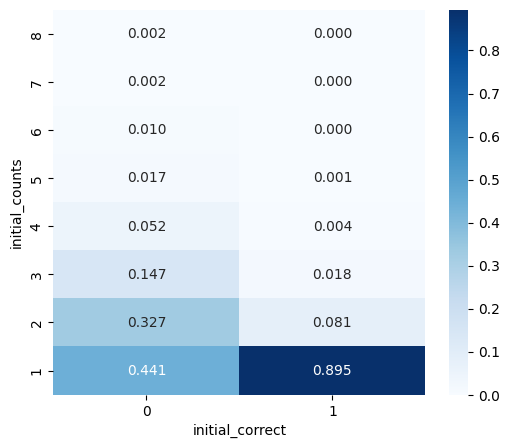

In [193]:
figsize(6,5)
ct = pd.crosstab(analysis['initial_counts'], analysis['initial_correct'], normalize='columns')
sns.heatmap(ct.iloc[::-1], annot=True, fmt='.3f', cmap='Blues')

<Axes: xlabel='repeat_correct', ylabel='repeat_counts'>

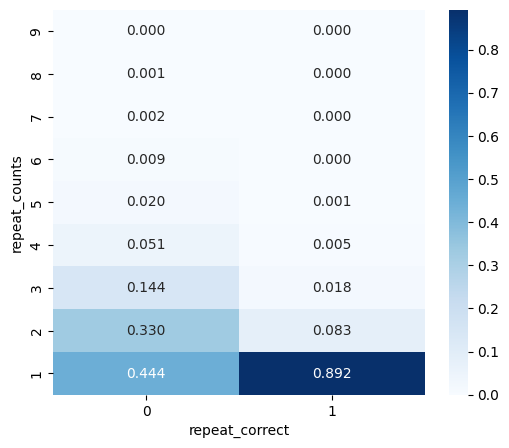

In [194]:
ct = pd.crosstab(analysis['repeat_counts'], analysis['repeat_correct'], normalize='columns')
sns.heatmap(ct.iloc[::-1], annot=True, fmt='.3f', cmap='Blues')

The relationship between correctness and number of outputs is the same pre and post repeat. Same, strong relationship as before.

#### pre-post repetition analysis

Text(0.5, 1.0, 'Column normalized')

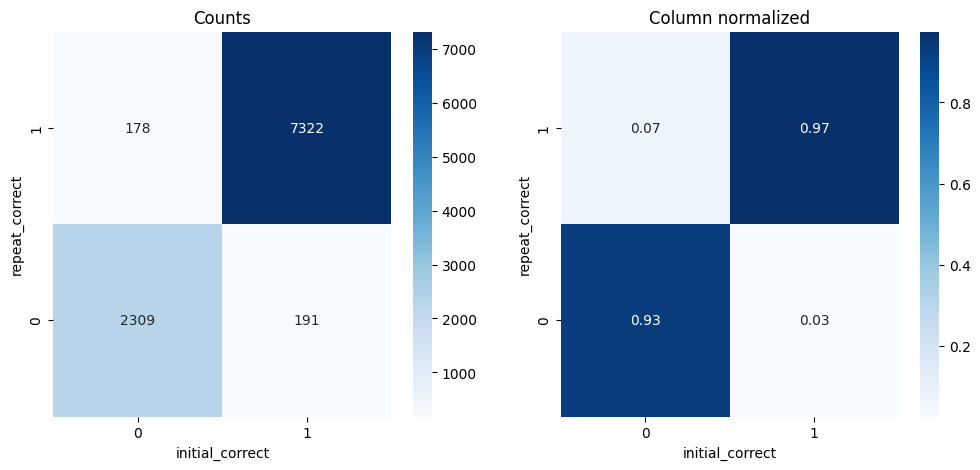

In [197]:
figsize(12, 5)
plt.subplots(1,2)

plt.subplot(1,2,1)
plt.title('Counts')
ct = pd.crosstab(analysis['repeat_correct'], analysis['initial_correct'] )
sns.heatmap(ct.iloc[::-1], annot=True, fmt='d', cmap='Blues')

plt.subplot(1,2,2)
ct = pd.crosstab(analysis['repeat_correct'], analysis['initial_correct'], normalize='columns')
sns.heatmap(ct.iloc[::-1], annot=True, fmt='.2f', cmap='Blues')
plt.title('Column normalized')



There were some changes in the outputs, but very few overall. Slightly more changed to wrong than to right. However, wrong were slightly more likely to change than right.

<Axes: xlabel='initial_counts', ylabel='repeat_counts'>

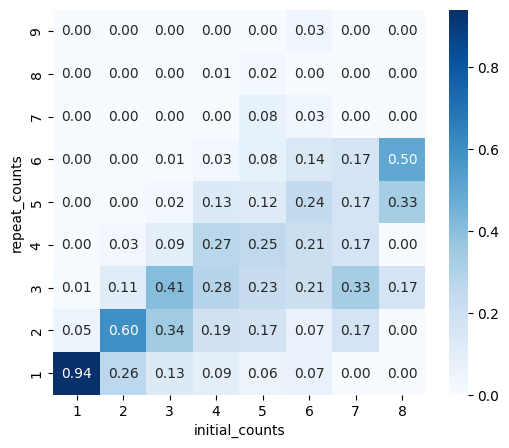

In [235]:
figsize(6,5)
ct = pd.crosstab(analysis['repeat_counts'], analysis['initial_counts'], normalize='columns')
sns.heatmap(ct.iloc[::-1], annot=True, fmt='.2f', cmap='Blues')

In [297]:
analysis['repeat_counts'].sum()

np.int64(13350)

In [298]:
analysis['initial_counts'].sum()

np.int64(13340)

The number of outputs are well correlated, but there is a general trend to _decrease_ the number of outputs.

This holds at the level of pairs, but not overall.

#### answer changes vs counts

In [199]:
analysis['changed_answer'] = (analysis['initial_correct'] != analysis['repeat_correct']).astype(int)
analysis['count_change'] = (analysis['repeat_counts'] - analysis['initial_counts'])

Text(0.5, 1.0, 'Row normalized')

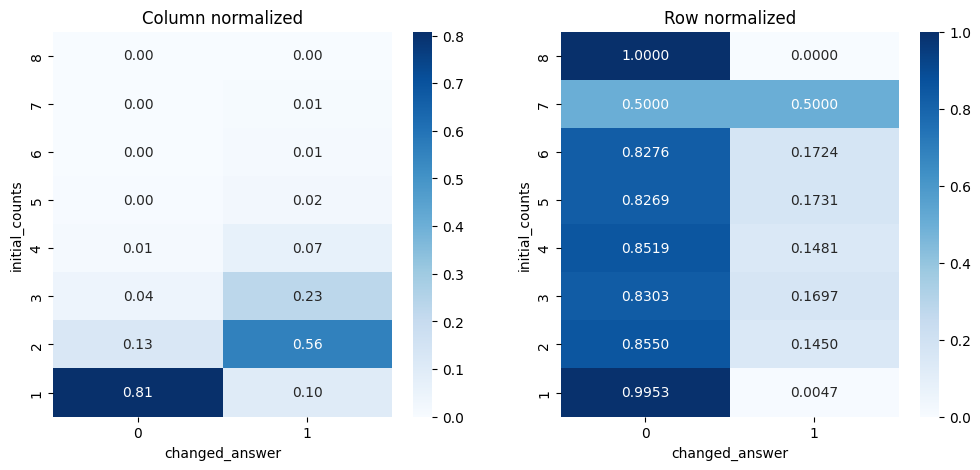

In [200]:
figsize(12, 5)
plt.subplots(1,2)

plt.subplot(1,2,1)
plt.title('Column normalized')
ct = pd.crosstab(analysis['initial_counts'], analysis['changed_answer'], normalize='columns')
sns.heatmap(ct.iloc[::-1], annot=True, fmt='.2f', cmap='Blues')

plt.subplot(1,2,2)
ct = pd.crosstab(analysis['initial_counts'], analysis['changed_answer'], normalize='index')
sns.heatmap(ct.iloc[::-1], annot=True, fmt='.4f', cmap='Blues')
plt.title('Row normalized')

This interesting: most of the cases where the answer changed had multiple decodings initially! For most cases with initial counts > 1, about 16% of the answers changed.


<Axes: xlabel='count_change', ylabel='Count'>

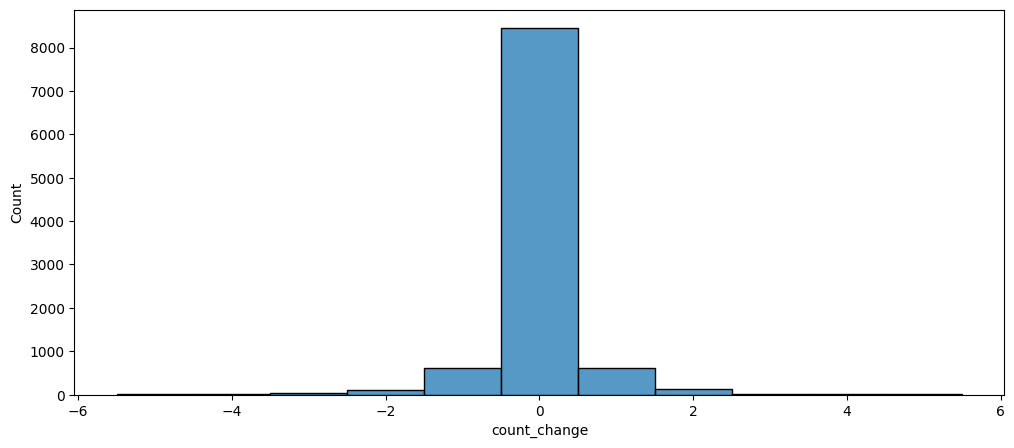

In [201]:
sns.histplot(analysis, x='count_change', discrete=True)

Reasonably centered count changes. 

#### answer changes vs count changes

<Axes: xlabel='changed_answer', ylabel='count_change'>

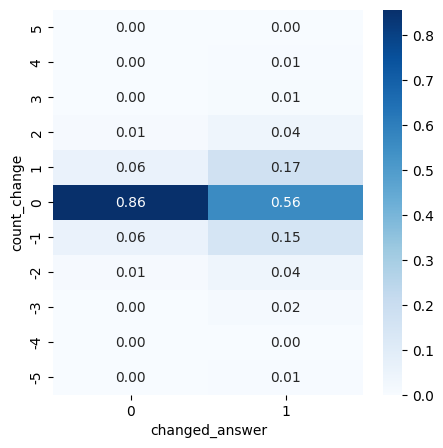

In [202]:
figsize(5,5)
ct = pd.crosstab(analysis['count_change'], analysis['changed_answer'], normalize='columns')
sns.heatmap(ct.iloc[::-1], annot=True, fmt='.2f', cmap='Blues')

This appears to simply reflect the same thing as above.

In [203]:
analysis['answer_delta'] =  analysis['repeat_correct'] -analysis['initial_correct']

Text(0.5, 1.0, 'Row normalized')

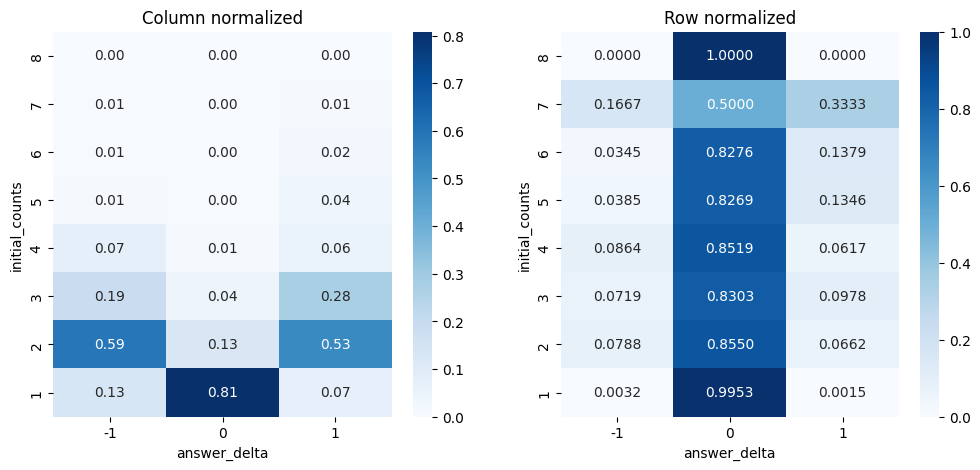

In [204]:
figsize(12, 5)
plt.subplots(1,2)

plt.subplot(1,2,1)
plt.title('Column normalized')
ct = pd.crosstab(analysis['initial_counts'], analysis['answer_delta'], normalize='columns')
sns.heatmap(ct.iloc[::-1], annot=True, fmt='.2f', cmap='Blues')

plt.subplot(1,2,2)
ct = pd.crosstab(analysis['initial_counts'], analysis['answer_delta'], normalize='index')
sns.heatmap(ct.iloc[::-1], annot=True, fmt='.4f', cmap='Blues')
plt.title('Row normalized')

There appears to be little difference in the initial counts to distinguish improvements from decreases.

Text(0.5, 1.0, 'Row normalized')

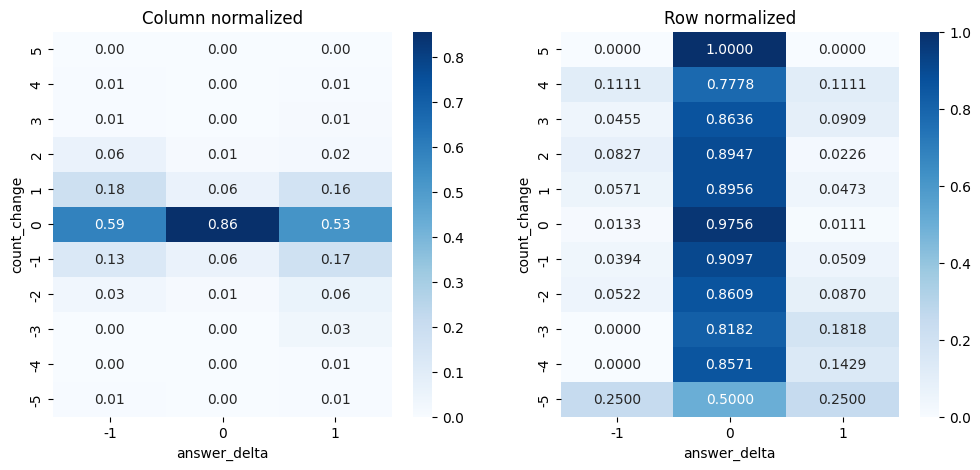

In [205]:
figsize(12, 5)
plt.subplots(1,2)

plt.subplot(1,2,1)
plt.title('Column normalized')
ct = pd.crosstab(analysis['count_change'], analysis['answer_delta'], normalize='columns')
sns.heatmap(ct.iloc[::-1], annot=True, fmt='.2f', cmap='Blues')

plt.subplot(1,2,2)
ct = pd.crosstab(analysis['count_change'], analysis['answer_delta'], normalize='index')
sns.heatmap(ct.iloc[::-1], annot=True, fmt='.4f', cmap='Blues')
plt.title('Row normalized')

Similarly interestingly null: the change in the counts and the change in the answers doesn't show much relationship. However, the effect may also be washed out by the strong middle column

In [206]:
filtered = analysis[ analysis['changed_answer'].astype(bool) ]

Text(0.5, 1.0, 'Column normalized')

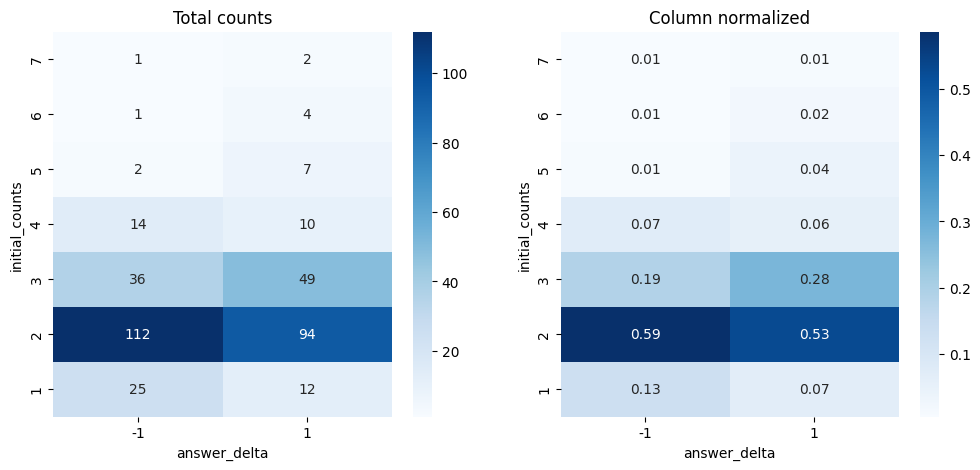

In [207]:
figsize(12, 5)
plt.subplots(1,2)

plt.subplot(1,2,1)
plt.title('Total counts')
ct = pd.crosstab(filtered['initial_counts'], filtered['answer_delta'])
sns.heatmap(ct.iloc[::-1], annot=True, fmt='d', cmap='Blues')

plt.subplot(1,2,2)
ct = pd.crosstab(filtered['initial_counts'], filtered['answer_delta'], normalize='columns')
sns.heatmap(ct.iloc[::-1], annot=True, fmt='.2f', cmap='Blues')
plt.title('Column normalized')

Text(0.5, 1.0, 'Column normalized')

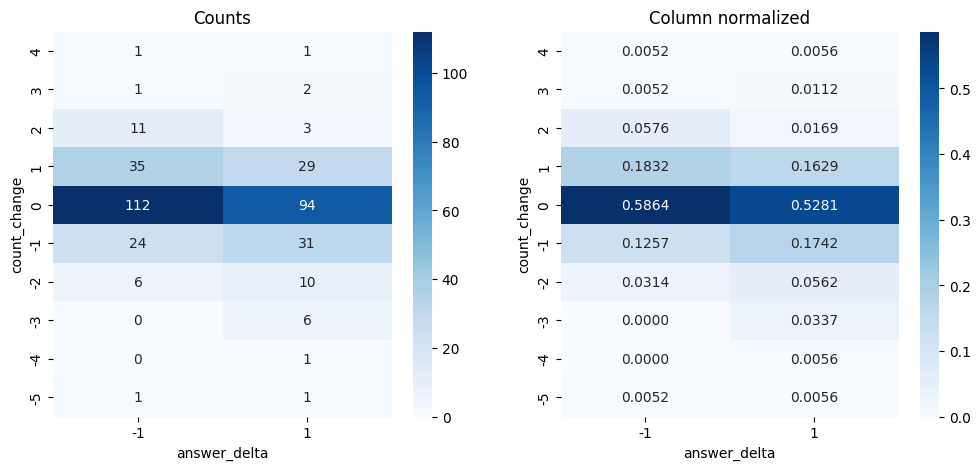

In [209]:
figsize(12, 5)
plt.subplots(1,2)

plt.subplot(1,2,1)
plt.title('Counts')
ct = pd.crosstab(filtered['count_change'], filtered['answer_delta'])
sns.heatmap(ct.iloc[::-1], annot=True, fmt='d', cmap='Blues')

plt.subplot(1,2,2)
ct = pd.crosstab(filtered['count_change'], filtered['answer_delta'], normalize='columns')
sns.heatmap(ct.iloc[::-1], annot=True, fmt='.4f', cmap='Blues')
plt.title('Column normalized')

The column normalized version shows us the relationship, insofar as it exists (Note that these are very small sample sizes). Very weakly, answers that _became wrong_ started with _fewer_ decoded options and showed larger _increases_ in the number of outputs. Answers that became right had _more_ initial decodings, and showed on average not change in the number of outputs.

This is really, not significant, so lets not over interpret.



In [210]:
analysis['count_change_sign'] = np.sign(analysis['count_change'])
filtered = analysis[ analysis['changed_answer'].astype(bool) ]

Text(0.5, 1.0, 'Column normalized')

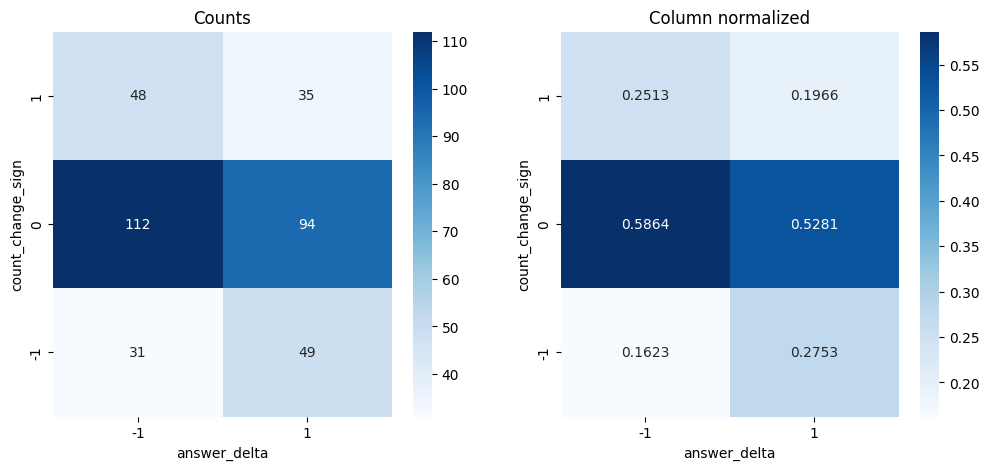

In [211]:
figsize(12, 5)
plt.subplots(1,2)

plt.subplot(1,2,1)
plt.title('Counts')
ct = pd.crosstab(filtered['count_change_sign'], filtered['answer_delta'])
sns.heatmap(ct.iloc[::-1], annot=True, fmt='d', cmap='Blues')

plt.subplot(1,2,2)
ct = pd.crosstab(filtered['count_change_sign'], filtered['answer_delta'], normalize='columns')
sns.heatmap(ct.iloc[::-1], annot=True, fmt='.4f', cmap='Blues')
plt.title('Column normalized')

30 vs 50 increase vs decrease. This is something that we can actually do real statistics on. Answers that became wrong showed a _increase_ in the number of unique decoded values. Answers that became right showed a _decrease_ in the number of unique decoded values.



#### Was the answer in the initial cloud? Does this predict anything?

In [212]:
initial_has_gt = []
for i, row in enumerate(test_dataset['predictions']):
    has_gt = int(test_dataset['gts'][i] in row.unique())
    initial_has_gt.append(has_gt)


In [213]:
repeat_has_gt = []
for i, row in enumerate(repeat_predictions):
    has_gt = int(test_dataset['gts'][i] in row.unique())
    repeat_has_gt.append(has_gt)


In [214]:
analysis['initial_has_gt'] = initial_has_gt
analysis['repeat_has_gt'] = repeat_has_gt

In [215]:
filtered = analysis[ analysis['changed_answer'].astype(bool) ]

<Axes: xlabel='initial_has_gt', ylabel='answer_delta'>

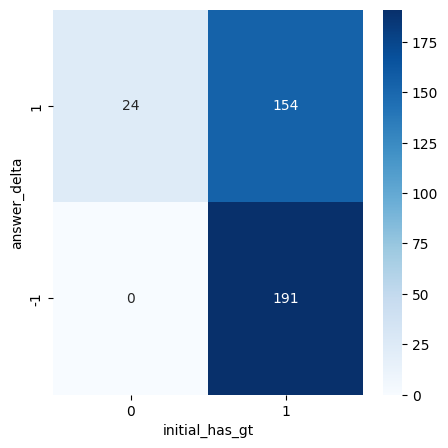

In [220]:
figsize(5,5)
ct = pd.crosstab(filtered['answer_delta'], filtered['initial_has_gt'])
sns.heatmap(ct.iloc[::-1], annot=True, fmt='d', cmap='Blues')

- More decrease than improvement when it had the ground truth.
- There was _never_ loss when the initial cloud was lacking the ground truth. 

The second one _must_ hold: cases without gt answers can be right initially.


Text(0.5, 1.0, 'Column normalized')

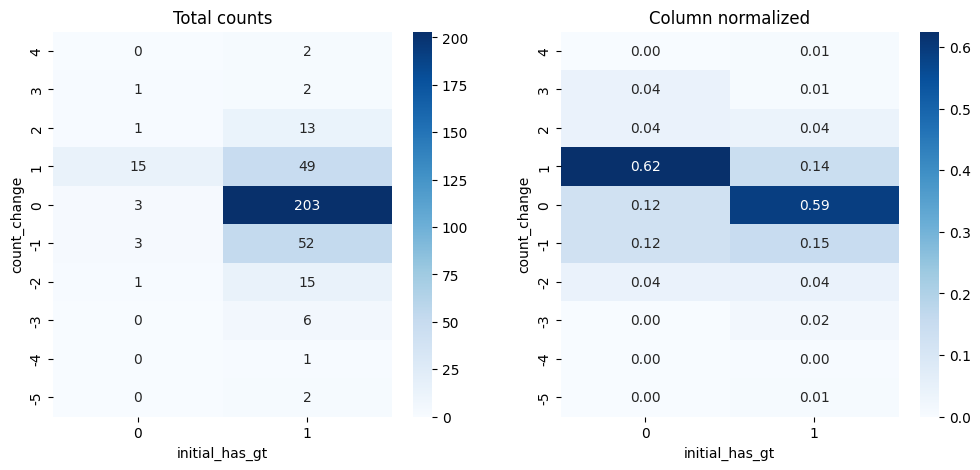

In [217]:
figsize(12, 5)
plt.subplots(1,2)

plt.subplot(1,2,1)
plt.title('Total counts')
ct = pd.crosstab(filtered['count_change'], filtered['initial_has_gt'])
sns.heatmap(ct.iloc[::-1], annot=True, fmt='d', cmap='Blues')

plt.subplot(1,2,2)
ct = pd.crosstab(filtered['count_change'], filtered['initial_has_gt'], normalize='columns')
sns.heatmap(ct.iloc[::-1], annot=True, fmt='.2f', cmap='Blues')
plt.title('Column normalized')

Text(0.5, 1.0, 'Column normalized')

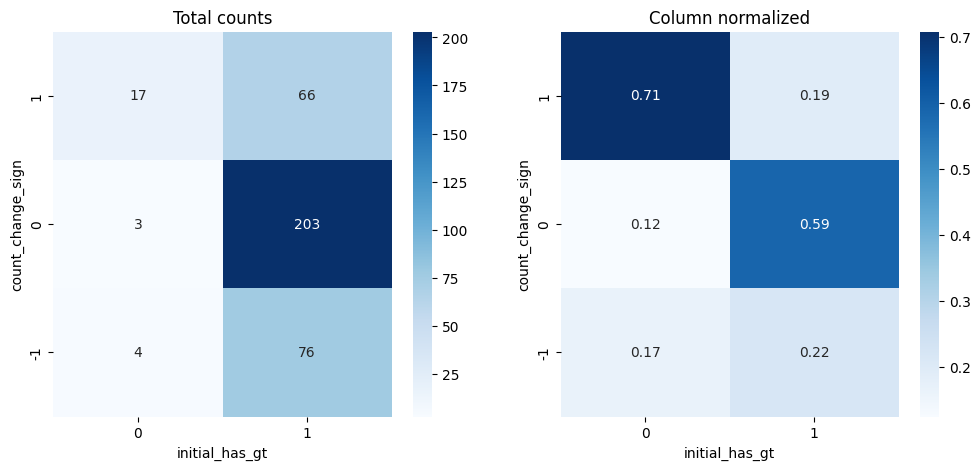

In [218]:
figsize(12, 5)
plt.subplots(1,2)

plt.subplot(1,2,1)
plt.title('Total counts')
ct = pd.crosstab(filtered['count_change_sign'], filtered['initial_has_gt'])
sns.heatmap(ct.iloc[::-1], annot=True, fmt='d', cmap='Blues')

plt.subplot(1,2,2)
ct = pd.crosstab(filtered['count_change_sign'], filtered['initial_has_gt'], normalize='columns')
sns.heatmap(ct.iloc[::-1], annot=True, fmt='.2f', cmap='Blues')
plt.title('Column normalized')

Perhaps there is a relationship here: conditioning on answer changing, those without the ground truth showed increased counts on average. Those with showed no bias in the number of changes. 

However, I think that the conditioning here has a strong explaining away effect: no gt -> False -> more likely to change


#### Key point summary

1. More answers switched to wrong that to right. (_weak_)
2. Repetition _decreased_ the number of unique decodings. (paired)
3. Most of the cases where the answer changed had multiple decodings initially (__strong__)
4. Answers that became wrong showed a increase in the number of unique decoded values.
5. Answers that became right showed a decrease in the number of unique decoded values.
6. Cases without the ground truth in initial cloud showed increased counts on average


Combining 1, 2, 3, 4 we can guess that many answers that stayed unchanged also was changes in the number of unique decoded values

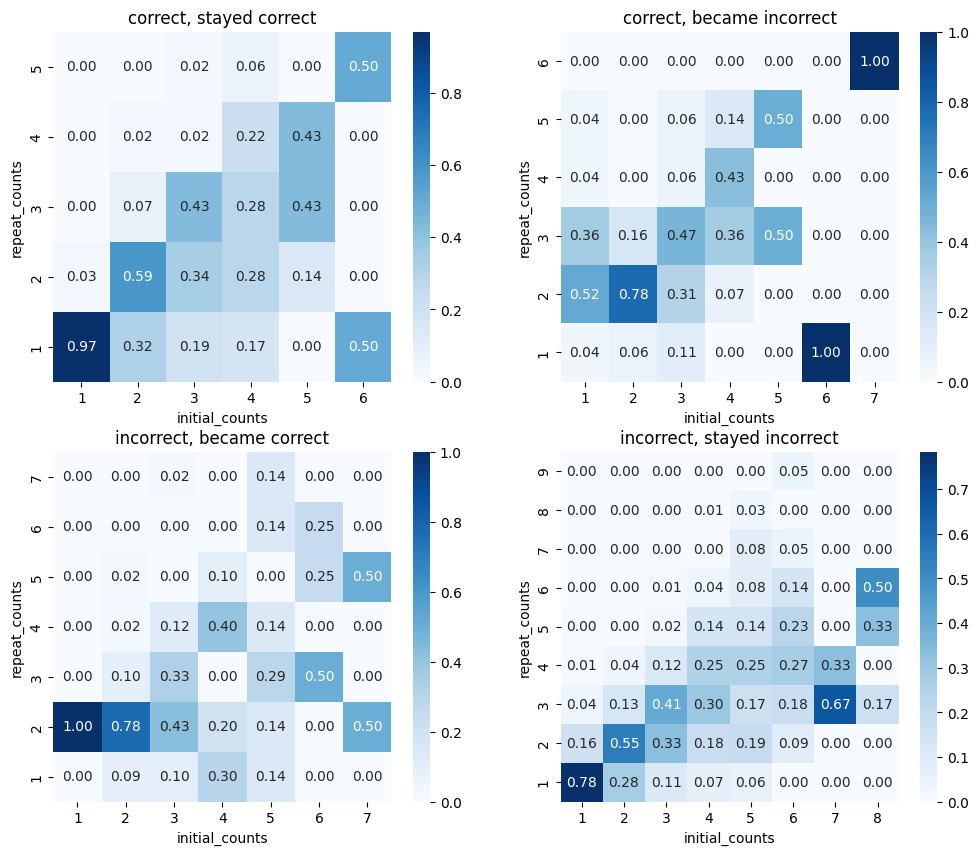

In [300]:
def plot_counts_dist(df, ax):
    ct = pd.crosstab(df['repeat_counts'], df['initial_counts'], normalize='columns')
    sns.heatmap(ct.iloc[::-1], annot=True, fmt='.2f', cmap='Blues', ax=ax)

figsize(12, 10)
plt.subplots(2,2)

ax = plt.subplot(2,2,1)
ax.set_title('correct, stayed correct')
df = analysis[ (analysis['initial_correct'] ==1) & (analysis['repeat_correct'] ==1)]
plot_counts_dist(df, ax)

ax = plt.subplot(2,2,2)
ax.set_title('correct, became incorrect')
df = analysis[ (analysis['initial_correct'] ==1) & (analysis['repeat_correct'] ==0)]
plot_counts_dist(df, ax)

ax = plt.subplot(2,2,3)
ax.set_title('incorrect, became correct')
df = analysis[ (analysis['initial_correct'] ==0) & (analysis['repeat_correct'] ==1)]
plot_counts_dist(df, ax)

ax = plt.subplot(2,2,4)
ax.set_title('incorrect, stayed incorrect')
df = analysis[ (analysis['initial_correct'] ==0) & (analysis['repeat_correct'] ==0)]
plot_counts_dist(df, ax)

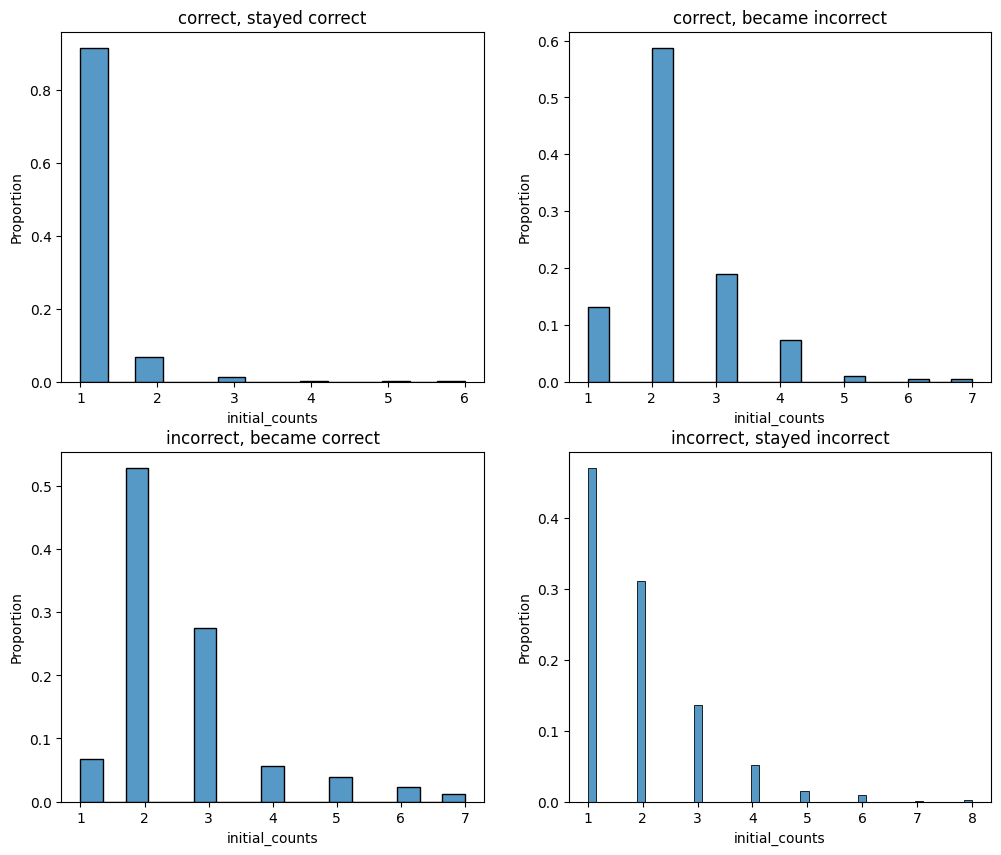

In [268]:
def plot_initial_hist(df, ax):
    sns.histplot(df, x='initial_counts', stat='proportion', ax=ax)

figsize(12, 10)
plt.subplots(2,2)

ax = plt.subplot(2,2,1)
ax.set_title('correct, stayed correct')
df = analysis[ (analysis['initial_correct'] ==1) & (analysis['repeat_correct'] ==1)]
plot_initial_hist(df, ax)

ax = plt.subplot(2,2,2)
ax.set_title('correct, became incorrect')
df = analysis[ (analysis['initial_correct'] ==1) & (analysis['repeat_correct'] ==0)]
plot_initial_hist(df, ax)

ax = plt.subplot(2,2,3)
ax.set_title('incorrect, became correct')
df = analysis[ (analysis['initial_correct'] ==0) & (analysis['repeat_correct'] ==1)]
plot_initial_hist(df, ax)

ax = plt.subplot(2,2,4)
ax.set_title('incorrect, stayed incorrect')
df = analysis[ (analysis['initial_correct'] ==0) & (analysis['repeat_correct'] ==0)]
plot_initial_hist(df, ax)

What if we just applied the remapping when multiple outputs were detected?

<Axes: xlabel='initial_correct', ylabel='repeat_correct'>

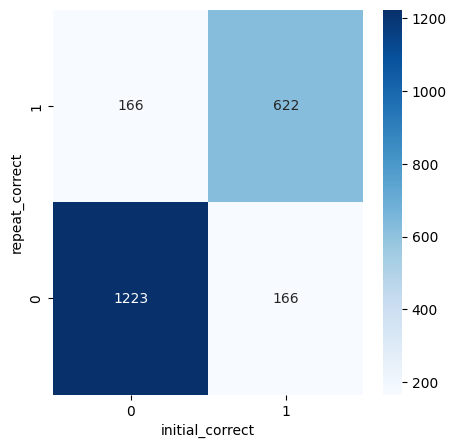

In [293]:
figsize(5,5)
filtered = analysis[ analysis['initial_counts'] >1]
ct = pd.crosstab(filtered['repeat_correct'], filtered['initial_correct'],)
sns.heatmap(ct.iloc[::-1], annot=True, fmt='d', cmap='Blues')

In [281]:
mout_pre = analysis[ analysis['initial_counts'] > 1 ]['initial_correct'].mean().item()
mout_post = analysis[ analysis['initial_counts'] > 1 ]['repeat_correct'].mean().item()

print(f'initial multi-out accuracy {mout_pre:.3f}')
print(f'rerun multi-out accuracy {mout_post:.3f}')

initial multi-out accuracy 0.362
rerun multi-out accuracy 0.362


Nope. The outputs are just as likely to be correct after the second pass as after the first.

#### Analysis:

- It appear that there is a general tendency to decrease the diversity of the set. This makes sense: the resamples were less diverse than the initial samples.

- However, those cases that started with a single (or two) outputs and changed their answer, generally become more diverse: perhaps the old answer was also coming out of the network.

- Those that change strongly come from cases with multiple initial answers: perhaps they are able to 'resample' more effectively.

- Conditioning on having multiple outputs initially is _not_ enough to make a second pass helpful: it is exactly break even.

Overall, I think this data can pretty much all be exlained by the relationship between multiple decoding and wrong values, and lower varaince in activity space. Not much more to say.



## Activity analysis

In [2]:
test_dataset = torch.load('activity_data_test.pt')
activity = test_dataset['activity'].reshape(-1, 768)

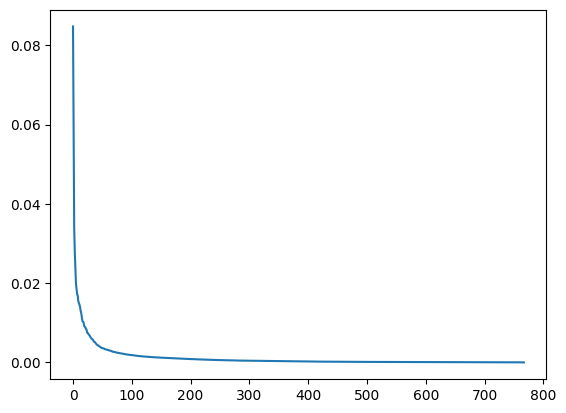

In [3]:
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(activity)
plt.plot( pca.explained_variance_ratio_)

The first 100 - 150 PCs seems like enough

In [4]:
from sklearn.base import BaseEstimator
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

class PCAGMMGenerator(BaseEstimator):
    """
    A generative model wrapping PCA and GMM for sampling.
    """
    def __init__(self, n_components=150, n_clusters=20, random_state=None):
        self.n_components = n_components
        self.n_clusters = n_clusters
        self.random_state = random_state

        # The internal pipeline for fitting/forward transformation
        self.pca = PCA(n_components=self.n_components, random_state=self.random_state)
        self.gmm = GaussianMixture(n_components=self.n_clusters, random_state=self.random_state)
        
        self.pipeline_ = Pipeline([
            ('pca', self.pca),
            ('gmm', self.gmm) # GMM is the final estimator, fit only
        ])

    def fit(self, X, y=None):
        """Fit the PCA to reduce dimension, then fit the GMM on the transformed data."""
        
        # 1. Fit PCA
        X_reduced = self.pca.fit_transform(X)
        
        # 2. Fit GMM on the reduced data
        self.gmm.fit(X_reduced)
        
        return self

    def sample(self, n_samples=1):
        """
        Generates new data by sampling from the GMM and 
        inverse transforming the result using the fitted PCA.
        """
        if not hasattr(self.gmm, 'means_'):
            raise ValueError("Model has not been fitted yet. Call 'fit' first.")

        # 1. Sample from the fitted GMM and inverse transform to high dimensions
        X_sampled_reduced, _ = self.gmm.sample(n_samples)
        X_sampled_original = self.pca.inverse_transform(X_sampled_reduced)
        
        return X_sampled_original




In [5]:
model = PCAGMMGenerator(n_clusters=20, n_components=50)
split = activity.shape[0] // 2

train = activity[0:split]
test = activity[split:]

In [6]:
model.fit(train)

PCAGMMGenerator(n_components=50)

### Developing measures of goodness of fit.

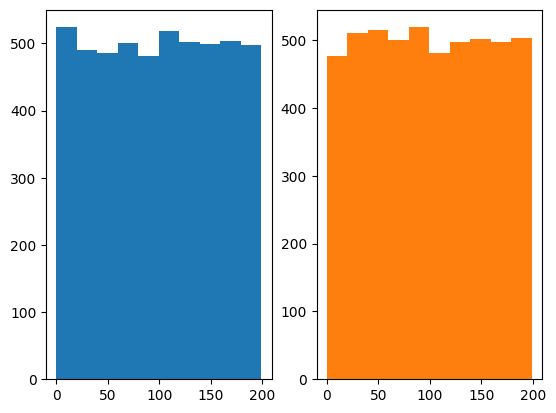

In [7]:
plt.subplots(1,2)
plt.subplot(1,2,1)
_=plt.hist(test_dataset['gts'][0:10000//2], color='C0')

plt.subplot(1,2,2)
_=plt.hist(test_dataset['gts'][10000//2:], color='C1')

Small differences in class composition. This _shouldn't_ matter for any sampler.

In [8]:
from ignite.metrics import MaximumMeanDiscrepancy
from ignite.engine import Engine

In [212]:
from sklearn.model_selection import ShuffleSplit

def eval_step(engine, batch):
    return batch

default_evaluator = Engine(eval_step)

metric = MaximumMeanDiscrepancy()
metric.attach(default_evaluator, "mmd")

def MMD(data1, data2, batch_size=16, n_splits=10, paired_splits=True):
    data1 = torch.as_tensor(data1, dtype=torch.float)
    data2 = torch.as_tensor(data2, dtype=torch.float)


    if n_splits == 1:
        state = default_evaluator.run([data1.view(batch_size, data1.shape[0] // batch_size, 768),
                                       data2.view(batch_size, data2.shape[0] // batch_size, 768)])
        return state.metrics['mmd']

    elif paired_splits:
        ss = ShuffleSplit(n_splits=n_splits, test_size=0.7)
        distances = []
        
        for _, inds in tqdm(ss.split(data1), total=n_splits):
            d1 = data1[inds]
            d2 = data2[inds]

            state = default_evaluator.run([d1.view(batch_size, d1.shape[0] // batch_size, 768),
                                           d2.view(batch_size, d2.shape[0] // batch_size, 768)])
    
            distances.append( state.metrics['mmd'] )
        return distances

    else:
        ss1 = ShuffleSplit(n_splits=n_splits, test_size=0.7)
        ss2 = ShuffleSplit(n_splits=n_splits, test_size=0.7)
        distances = []
        
        for _, inds_pair in zip(ss.split(data1), ss.split(data2)):
            d1 = data1[inds_pair[0]]
            d2 = data2[inds_pair[1]]

            state = default_evaluator.run([d1.view(batch_size, d1.shape[0] // batch_size, 768),
                                           d2.view(batch_size, d2.shape[0] // batch_size, 768)])
    
            distances.append( state.metrics['mmd'] )
        return distances

    
    

In [213]:
tr_tr = MMD(train, train, n_splits=15, batch_size=8)
tr_test = MMD(train, test, n_splits=15, batch_size=8) 

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [01:57<00:00,  7.86s/it]


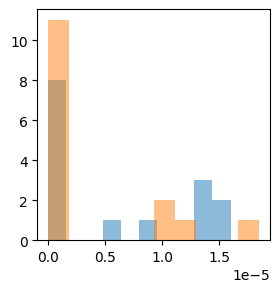

In [214]:
figsize(3,3)
plt.hist(tr_tr, alpha=0.5)
_=plt.hist(tr_test, alpha=0.5)

These are the same distribution, so this is reasonable.

In [215]:
samples = model.sample(250000)

In [216]:
tr_samples = MMD(train, samples, n_splits=15, batch_size=8)
test_samples = MMD(test, samples, n_splits=15, batch_size=8)

  0%|                                                                                                                                 | 0/15 [00:04<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
figsize(3,3)
plt.hist(tr_test, alpha=0.5)
_=plt.hist(tr_samples, alpha=0.5)

In [ ]:
figsize(3,3)
plt.hist(tr_test, alpha=0.5)
_=plt.hist(test_samples, alpha=0.5)

These are worse, but not as much worse as whole dataset evaluations look.

In [178]:
 MMD(train, samples, n_splits=1)

0.004991908557713032

In [211]:
test_samples

[6.45722757326439e-05,
 9.025206236401573e-05,
 0.00010164128616452217,
 0.0,
 0.0,
 2.7083342502010055e-05,
 2.0106475858483464e-05,
 8.183559111785144e-05,
 7.952751911943778e-05,
 0.0,
 4.693395385402255e-05,
 3.1056708394316956e-05,
 8.469197200611234e-05,
 7.851178816054016e-05,
 0.0]

In [175]:
tr_samples_unpaired = MMD(train, samples, n_splits=15)
test_samples_unpaired = MMD(test, samples, n_splits=15)

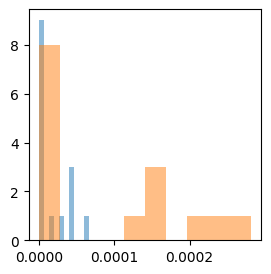

In [176]:
figsize(3,3)
plt.hist(tr_test, alpha=0.5)
_=plt.hist(tr_samples, alpha=0.5)

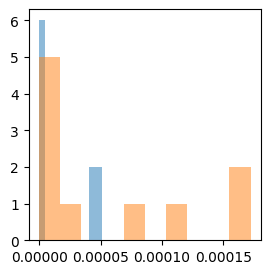

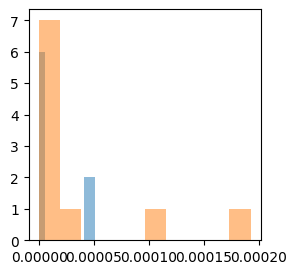

Train -> test MMD is significantly lower than train -> samples or test -> samples, which are similar.

In [154]:

ss = ShuffleSplit(n_splits=10, test_size=0.2)
ss2 = ShuffleSplit(n_splits=10, test_size=0.2)

In [155]:
i1 = ss.split(train)
i2 = ss2.split(test)

In [156]:
next(i1)[1] == next(i2)[1]

array([False, False, False, ..., False, False, False], shape=(50000,))

In [49]:
for i, pair in enumerate(kf.split(train, test)):
    print(i)

0
1
2
3
4


In [56]:
pair[1].shape

(50000,)

In [54]:
train.shape[0]

250000

In [58]:
test.shape[0]

250000

In [8]:
from sklearn.manifold import TSNE

all_data = np.concat( [test.numpy(), model.sample(50000)])
source = np.concat( [np.zeros(50000), np.ones(50000)])

tsne = TSNE()
outs = tsne.fit_transform(all_data)

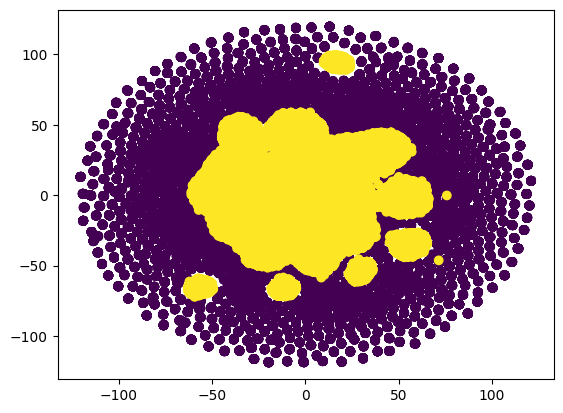

In [9]:
plt.scatter(outs[:,0], outs[:,1], c=source)

Hmmmmm. TSNE shows a strong separation between activity and samples. The ground truth (purple) appears to be more 'spread' that the fits.

In [10]:
from sklearn.manifold import TSNE

all_data = np.concat( [train.numpy()[np.random.choice(range(5000), 500)], model.sample(500)])
source = np.concat( [np.zeros(500), np.ones(500)])

tsne = TSNE()
outs = tsne.fit_transform(all_data)

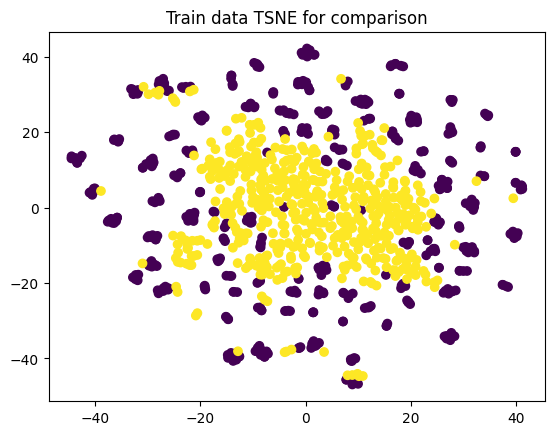

In [11]:
plt.title('Train data TSNE for comparison')
plt.scatter(outs[:,0], outs[:,1], c=source)

^ It looks like the GMM does capture the training data well.